# Week 4 Lab — SOLUTIONS — Diagnostic Testing: Violations of the OLS Assumptions

**MANG2074 Financial Econometrics 1**

**Objectives**

- Test for heteroscedasticity (Breusch–Pagan, White) and apply robust (HC/HAC) standard errors.
- Test for autocorrelation (Durbin–Watson, Breusch–Godfrey).
- Test residual normality (Jarque–Bera) and handle outliers with impulse dummies.
- Diagnose multicollinearity (correlation matrix, VIF), functional form (RESET) and parameter stability (Chow test).

**Data**

- `../data/macro.csv` — the Week 3 APT-style model for Microsoft.
- `../data/capm.csv` — the Week 2 CAPM regression for Ford (Chow test).


## Setup — rebuild the Week 3 model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import (het_breuschpagan, het_white,
                                          acorr_breusch_godfrey, linear_reset)
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# --- rebuild the Week 3 dataset and APT-style model ---
raw = pd.read_csv('../data/macro.csv', index_col=0, parse_dates=True)

def logdiff(x):
    return 100 * np.log(x / x.shift(1))

data = pd.DataFrame({
    'ermsoft':    logdiff(raw['MICROSOFT']) - raw['USTB3M'] / 12,
    'ersandp':    logdiff(raw['SANDP']) - raw['USTB3M'] / 12,
    'dprod':      raw['INDPRO'].diff(),
    'dcredit':    raw['CCREDIT'].diff(),
    'dinflation': logdiff(raw['CPI']).diff(),
    'dmoney':     raw['M1SUPPLY'].diff(),
    'dspread':    raw['BMINUSA'].diff(),
    'rterm':      (raw['USTB10Y'] - raw['USTB3M']).diff(),
}).dropna()

formula = 'ermsoft ~ ersandp + dprod + dcredit + dinflation + dmoney + dspread + rterm'
results = smf.ols(formula, data).fit()
print(results.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.3260      0.475      2.789      0.006       0.391       2.261
ersandp        1.2808      0.094     13.574      0.000       1.095       1.466
dprod         -0.3030      0.737     -0.411      0.681      -1.752       1.146
dcredit       -0.0254      0.027     -0.934      0.351      -0.079       0.028
dinflation     2.1947      1.264      1.736      0.083      -0.291       4.681
dmoney        -0.0069      0.016     -0.441      0.659      -0.037       0.024
dspread        2.2601      4.140      0.546      0.585      -5.881      10.401
rterm          4.7331      1.716      2.758      0.006       1.359       8.107


## Task 1 — Look before you test

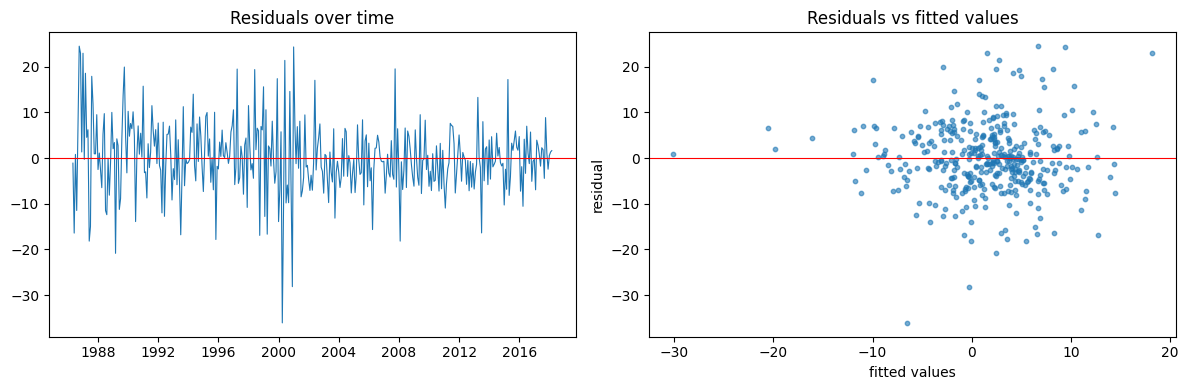

In [2]:
resid = results.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(resid, lw=0.8)
axes[0].axhline(0, color='red', lw=0.8)
axes[0].set_title('Residuals over time')
axes[1].scatter(results.fittedvalues, resid, s=10, alpha=0.6)
axes[1].axhline(0, color='red', lw=0.8)
axes[1].set_xlabel('fitted values'); axes[1].set_ylabel('residual')
axes[1].set_title('Residuals vs fitted values')
plt.tight_layout(); plt.show()


**What to interpret.** The residuals fluctuate around zero with no obvious trend or fan-shape against the fitted values, but several spikes stand out — most dramatically around 2000 (the dot-com boom/bust hit Microsoft hard). Eyeballing suggests outliers rather than systematic heteroscedasticity; the tests will confirm.

## Task 2 — Heteroscedasticity tests

In [3]:
X = results.model.exog

bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(results.resid, X)
print(f"Breusch-Pagan: LM = {bp_lm:.3f}, p-value = {bp_p:.4f}")

w_lm, w_p, w_f, w_fp = het_white(results.resid, X)
print(f"White:         LM = {w_lm:.3f}, p-value = {w_p:.4f}")


Breusch-Pagan: LM = 3.161, p-value = 0.8698
White:         LM = 37.463, p-value = 0.3568


**What to interpret.** Both tests have $H_0$: homoscedasticity (constant error variance). The Breusch–Pagan p-value (~0.87) and the White p-value (~0.36) are far above 0.05, so we **do not reject** homoscedasticity for this monthly model. (Daily financial returns, by contrast, almost always fail these tests — see Week 7.) White is the more general test since its auxiliary regression includes squares and cross-products, picking up nonlinear forms of heteroscedasticity.

## Task 3 — Robust standard errors

In [4]:
res_hc = smf.ols(formula, data).fit(cov_type='HC1')
res_hac = smf.ols(formula, data).fit(cov_type='HAC', cov_kwds={'maxlags': 6})

comp = pd.DataFrame({'coef': results.params,
                     'SE (OLS)': results.bse,
                     'SE (White HC1)': res_hc.bse,
                     'SE (Newey-West, 6 lags)': res_hac.bse})
print(comp.round(4))


              coef  SE (OLS)  SE (White HC1)  SE (Newey-West, 6 lags)
Intercept   1.3260    0.4755          0.4591                   0.4974
ersandp     1.2808    0.0944          0.0930                   0.0988
dprod      -0.3030    0.7369          0.6345                   0.5161
dcredit    -0.0254    0.0271          0.0208                   0.0221
dinflation  2.1947    1.2643          1.3068                   1.2998
dmoney     -0.0069    0.0156          0.0109                   0.0108
dspread     2.2601    4.1403          3.4278                   2.8120
rterm       4.7331    1.7158          1.7265                   1.7401


**What to interpret.** The coefficient estimates are identical in all three columns — robust covariance estimation changes only the *standard errors*. Here the robust SEs barely differ from OLS SEs (consistent with Task 2 finding no heteroscedasticity), so no inference changes. Reporting convention in empirical finance: when in doubt, report Newey–West SEs — they are consistent under both heteroscedasticity and autocorrelation, and cost nothing when neither is present.

## Task 4 — Autocorrelation

In [5]:
dw = durbin_watson(results.resid)
rho_hat = 1 - dw / 2
print(f"Durbin-Watson = {dw:.3f}  (implied first-order residual autocorrelation = {rho_hat:.3f})")

bg_lm, bg_p, bg_f, bg_fp = acorr_breusch_godfrey(results, nlags=12)
print(f"Breusch-Godfrey (12 lags): LM = {bg_lm:.3f}, p-value = {bg_p:.4f}")


Durbin-Watson = 2.097  (implied first-order residual autocorrelation = -0.049)
Breusch-Godfrey (12 lags): LM = 6.053, p-value = 0.9134


**What to interpret.** DW ≈ 2.10, i.e. an implied first-order autocorrelation of about −0.05 — essentially nothing. The Breusch–Godfrey LM test extends this to twelve lags jointly ($H_0$: no autocorrelation up to order 12) and its p-value (~0.91) confirms no serial correlation. BG is preferred because it (i) tests higher orders and (ii) remains valid when the regression contains lagged dependent variables, where DW is biased towards 2. Efficient-markets logic also makes large autocorrelation in monthly excess returns unlikely.

## Task 5 — Non-normality and outlier dummies

In [6]:
# (a) Jarque-Bera on the residuals
jb_stat, jb_p, sk, ku = jarque_bera(results.resid)
print(f"JB = {jb_stat:.2f}, p = {jb_p:.3g}, skewness = {sk:.3f}, kurtosis = {ku:.3f}")

# (b) biggest outliers
print("\nLargest absolute residuals:")
print(resid.abs().nlargest(5))

# (c) impulse dummies for the two dot-com months
data['apr00'] = (data.index == '2000-04-01').astype(float)
data['dec00'] = (data.index == '2000-12-01').astype(float)
results_dum = smf.ols(formula + ' + apr00 + dec00', data).fit()
print(results_dum.summary().tables[1])

jb2 = jarque_bera(results_dum.resid)
print(f"\nJB after dummies = {jb2[0]:.2f}, p = {jb2[1]:.3g}")


JB = 63.51, p = 1.62e-14, skewness = -0.006, kurtosis = 4.995

Largest absolute residuals:
Date
2000-04-01    36.075347
2000-12-01    28.143156
1986-10-01    24.479889
2001-01-01    24.309624
1986-11-01    22.948546
dtype: float64
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.4198      0.454      3.125      0.002       0.526       2.313
ersandp        1.2539      0.090     13.897      0.000       1.076       1.431
dprod         -0.3211      0.705     -0.456      0.649      -1.707       1.065
dcredit       -0.0157      0.026     -0.603      0.547      -0.067       0.035
dinflation     1.4421      1.215      1.187      0.236      -0.946       3.830
dmoney        -0.0057      0.015     -0.383      0.702      -0.035       0.024
dspread        1.8693      3.955      0.473      0.637      -5.908       9.647
rterm          4.2642      1.641      2.599      0.010    

**What to interpret.** JB ≈ 63 (p ≈ 0) — residual normality is rejected, driven by excess kurtosis from a handful of extreme months, the largest being April 2000 (−36%) and December 2000 (−28%), the bursting of the dot-com bubble. An impulse dummy equals 1 in one month and 0 elsewhere; mechanically it sets that month's residual to zero, so its coefficient (≈ −37 and −28, both highly significant) *is* the outlier. With the two dummies JB falls to ≈ 29: improved but still non-normal — financial returns are simply fat-tailed. With T ≈ 380 the central limit theorem means our t/F tests remain approximately valid anyway. Important honesty point: dummying out observations should be justified by an identifiable event, not used to launder inconvenient data.

## Task 6 — Multicollinearity

In [7]:
factors = ['ersandp', 'dprod', 'dcredit', 'dinflation', 'dmoney', 'dspread', 'rterm']
print(data[factors].corr().round(3))

Xc = sm.add_constant(data[factors])
vifs = pd.Series([variance_inflation_factor(Xc.values, i)
                  for i in range(1, Xc.shape[1])], index=factors)
print("\nVariance inflation factors:")
print(vifs.round(2))


            ersandp  dprod  dcredit  dinflation  dmoney  dspread  rterm
ersandp       1.000 -0.017    0.048      -0.002   0.037   -0.176 -0.046
dprod        -0.017  1.000    0.094      -0.144  -0.053   -0.053 -0.044
dcredit       0.048  0.094    1.000      -0.025   0.150    0.063 -0.004
dinflation   -0.002 -0.144   -0.025       1.000  -0.094   -0.227  0.042
dmoney        0.037 -0.053    0.150      -0.094   1.000    0.171  0.004
dspread      -0.176 -0.053    0.063      -0.227   0.171    1.000 -0.018
rterm        -0.046 -0.044   -0.004       0.042   0.004   -0.018  1.000

Variance inflation factors:
ersandp       1.05
dprod         1.05
dcredit       1.04
dinflation    1.09
dmoney        1.06
dspread       1.13
rterm         1.01
dtype: float64


**What to interpret.** The largest pairwise correlation is about 0.23 in absolute value and every VIF is below 1.2 (recall the trouble threshold is ~10). Multicollinearity is a non-issue here — by construction, since differencing macro variables removes the common trends that would otherwise make them collinear. Had the VIFs been large, the symptom would be individually insignificant t-ratios alongside a significant joint F (exactly the Week 3 pattern to watch for), and the remedies would be dropping/combining regressors or getting more data — not mechanical "fixes".

## Task 7 — Functional form: Ramsey RESET

In [8]:
reset = linear_reset(results, power=3, use_f=True)
print(reset)


<F test: F=1.2908401621047805, p=0.27626535022759807, df_denom=373, df_num=2>


**What to interpret.** RESET adds $\hat y_t^2$ and $\hat y_t^3$ to the regression; $H_0$: their coefficients are jointly zero, i.e. the linear functional form is adequate. With p ≈ 0.28 we do not reject — no evidence of neglected nonlinearity. (RESET is a portmanteau test: rejection says "something nonlinear is missing" without saying what.)

## Task 8 — Structural stability: Chow test on the Ford CAPM

In [9]:
capm = pd.read_csv('../data/capm.csv', index_col=0, parse_dates=True)
capm['erford'] = 100 * np.log(capm['FORD']).diff() - capm['USTB3M'] / 12
capm['ersandp'] = 100 * np.log(capm['SANDP']).diff() - capm['USTB3M'] / 12
capm = capm.dropna()

pooled = smf.ols('erford ~ ersandp', capm).fit()
pre = smf.ols('erford ~ ersandp', capm[:'2007-12-31']).fit()
post = smf.ols('erford ~ ersandp', capm['2008-01-01':]).fit()

print(f"beta pre-2008  = {pre.params['ersandp']:.3f}   (T = {int(pre.nobs)})")
print(f"beta post-2008 = {post.params['ersandp']:.3f}   (T = {int(post.nobs)})")

k = 2                          # parameters per regime (alpha, beta)
T = pooled.nobs
F = ((pooled.ssr - (pre.ssr + post.ssr)) / k) / ((pre.ssr + post.ssr) / (T - 2*k))
p = stats.f.sf(F, k, T - 2*k)
print(f"\nChow F = {F:.3f},  F({k}, {int(T-2*k)}) p-value = {p:.4f}")


beta pre-2008  = 1.776   (T = 71)
beta post-2008 = 1.922   (T = 122)

Chow F = 0.276,  F(2, 189) p-value = 0.7591


**What to interpret.** $H_0$: the CAPM parameters $(\alpha, \beta)$ are the same before and after January 2008. The sub-sample betas do differ numerically, and the printed p-value tells us whether that difference exceeds sampling noise: reject at 5% if p < 0.05. Two methodological notes: (i) the break date must be chosen *a priori* (Lehman/GFC is a legitimate ex-ante candidate) — picking the date that maximises F invalidates the stated distribution; (ii) an alternative to splitting the sample is interacting `ersandp` with a post-2008 dummy, which tests the same hypothesis and shows directly *which* parameter moved.

## Task 9 — Diagnostic report (model audit)

| Assumption | Test | Verdict | Action |
|---|---|---|---|
| Homoscedasticity | BP p≈0.87; White p≈0.36 | not rejected | none (robust SEs as insurance) |
| No autocorrelation | DW≈2.10; BG(12) p≈0.91 | not rejected | none |
| Normality | JB≈63, p≈0 | **rejected** | dot-com impulse dummies; CLT for inference |
| No multicollinearity | max VIF < 1.2 | fine | none |
| Functional form | RESET p≈0.28 | not rejected | none |
| Parameter stability | Chow at 2008 (CAPM) | see Task 8 | report sub-sample betas |

Overall: the APT model's inference is trustworthy apart from fat-tailed residuals, which are endemic to financial returns and handled by large-sample arguments plus event dummies.